In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import MINGLE as mg
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
file_path = r"/Volumes/data/MINGLE/Data/Intestine/05_25_HuBMAP_tunit.csv"
cells = mg.pp.read_file(file_path)

/Users/jamesw/Desktop/Mingle/src/MINGLE/pp/preprocessing.py:33: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
cluster_col = "Neighborhood"
neighborhood_col = "Community"
region_key = "unique_region"

In [4]:
centroids = mg.tl.centroid_Calculation(cells, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_col=region_key, k = 100)

Example dummy cols: ['Neighborhood__Adaptive Immune Enriched', 'Neighborhood__CD66+ Mature Epithelial', 'Neighborhood__CD8+ T Enriched IEL', 'Neighborhood__Glandular Epithelial', 'Neighborhood__Innate Immune Enriched']


/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/opt/anaconda3/lib/python3.13/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


{5:               x       y   unique_region             Neighborhood  \
0        3984.0  3387.0  B004_Ascending        Mature Epithelial   
1        5188.0  4116.0  B004_Ascending  Transit Amplifying Zone   
2        6070.0  3146.0  B004_Ascending   Innate Immune Enriched   
3        6792.0  3891.0  B004_Ascending           Outer Follicle   
4        7968.0  6351.0  B004_Ascending           Outer Follicle   
...         ...     ...             ...                      ...   
2511997  7633.0   353.0      B008_Trans        Innervated Stroma   
2511998  4921.0   533.0      B008_Trans                   Stroma   
2511999  3710.0  6049.0      B008_Trans                   Stroma   
2512000  5823.0   794.0      B008_Trans         Microvasculature   
2512001  2097.0  3363.0      B008_Trans                   Stroma   

         Adaptive Immune Enriched  CD66+ Mature Epithelial  \
0                             0.0                      0.0   
1                             0.0                      

In [5]:
windows = mg.tl.KNN2(cells, cluster_col=cluster_col,region_key=region_key)

Example dummy cols: ['Neighborhood__Adaptive Immune Enriched', 'Neighborhood__CD66+ Mature Epithelial', 'Neighborhood__CD8+ T Enriched IEL', 'Neighborhood__Glandular Epithelial', 'Neighborhood__Innate Immune Enriched']


In [6]:
centroids_df = pd.DataFrame(
    centroids.X,
    index=centroids.obs_names,
    columns=centroids.var_names,
)
centroids_df

,Mature Epithelial_mean,Mature Epithelial_std,Transit Amplifying Zone_mean,Transit Amplifying Zone_std,Innate Immune Enriched_mean,Innate Immune Enriched_std,Outer Follicle_mean,Outer Follicle_std,Adaptive Immune Enriched_mean,Adaptive Immune Enriched_std,...,Macrovasculature_mean,Macrovasculature_std,Smooth Muscle_mean,Smooth Muscle_std,Paneth Enriched_mean,Paneth Enriched_std,Stroma_mean,Stroma_std,Innervated Smooth Muscle_mean,Innervated Smooth Muscle_std
Community,,,,,,,,,,,,,,,,,,,,,
Plasma Cell Enriched,9.558386,11.537744,13.011317,9.920156,2.599044,4.336859,2.953207,4.839333,4.246700,5.328364,...,0.725821,1.908682,0.139992,1.091345,0.400171,2.163645,0.969395,2.789656,0.182432,0.917452
Mature Epithelial,62.687248,17.908857,6.971412,8.119434,1.910536,4.279317,0.490264,2.158075,1.107751,2.731903,...,0.448684,1.739128,0.069309,0.911272,0.161810,1.501657,0.577888,2.459871,0.123821,0.821211
Innate Immune Enriched,8.358431,10.273873,5.829022,6.320097,20.417200,14.319899,3.729206,5.740111,9.318308,10.139333,...,4.558730,5.586997,1.251654,3.621972,0.375031,1.962081,2.226917,5.153801,0.952596,2.570816
Follicle,0.600774,2.493524,2.344171,4.902575,2.075823,3.794854,34.531281,25.625643,10.294953,10.735452,...,0.598873,1.836810,0.672476,3.036565,0.900225,3.646360,0.855602,3.215506,0.375332,1.681897
Adaptive Immune Enriched,3.697472,6.421231,18.327370,12.049746,3.534961,4.628020,9.349175,8.850881,10.007776,9.368501,...,2.509362,3.939731,4.422360,7.001133,9.393415,14.585907,2.247353,4.660195,1.694949,3.438576
Secretory Epithelial,5.567675,8.902560,32.706554,23.548925,3.302454,5.183298,2.493332,4.600445,3.904611,5.252833,...,0.697595,1.997998,0.498465,2.426909,0.768097,3.287706,1.009369,2.848736,0.290013,1.292102
CD66+ Mature Epithelial,4.918949,8.313619,7.389808,7.951927,6.482994,7.624216,0.828088,2.696398,1.967965,4.441624,...,0.106854,0.991943,0.038959,0.846595,0.003116,0.147756,1.359685,3.948324,0.038036,0.388519
CD8+ T Enriched IEL,16.168381,14.174016,4.638322,5.892789,1.991880,3.556680,1.769749,4.127029,6.673748,8.086159,...,1.131265,2.658838,0.142535,1.112910,0.492418,2.462722,0.313738,1.710083,0.149241,0.901265
Stroma,0.223262,1.674036,0.740299,2.771394,2.521718,4.783629,0.798275,2.937136,0.951570,3.110195,...,12.818675,14.543368,4.304208,6.793388,0.143191,1.324513,34.703461,24.281429,5.954335,6.845966


In [7]:
mg.tl.cpu_gmm_probability(CELLS_ADATA=cells, CENTROIDS_ADATA=centroids, cluster_col=cluster_col, neighborhood_col=neighborhood_col, region_key=region_key, k = 100)

Example dummy cols: ['Neighborhood__Adaptive Immune Enriched', 'Neighborhood__CD66+ Mature Epithelial', 'Neighborhood__CD8+ T Enriched IEL', 'Neighborhood__Glandular Epithelial', 'Neighborhood__Innate Immune Enriched']
Using 14 processes.


/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/anaconda3/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprec

AnnData object with n_obs × n_vars = 2512002 × 0
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit'
    uns: 'neighborhood_probability_neighborhoods'
    obsm: 'neighborhood_probabilities'

In [8]:
cells.obsm['neighborhood_probabilities']

array([[9.71753762e-001, 1.95096769e-003, 1.81781736e-006, ...,
        1.52089720e-002, 4.18438078e-077, 1.04766908e-121],
       [3.75783012e-005, 9.99962100e-001, 4.31130152e-010, ...,
        1.29773624e-007, 2.90369102e-208, 0.00000000e+000],
       [5.38074990e-112, 0.00000000e+000, 7.37068231e-004, ...,
        0.00000000e+000, 9.99262932e-001, 3.00919978e-013],
       ...,
       [2.10886396e-157, 1.03266746e-202, 1.63309526e-019, ...,
        2.32709293e-138, 8.76596935e-001, 1.23403065e-001],
       [1.85583714e-243, 4.21680221e-296, 4.25461831e-031, ...,
        1.36463962e-251, 1.00000000e+000, 1.45204233e-010],
       [1.73429524e-200, 1.29067339e-282, 1.53345931e-022, ...,
        0.00000000e+000, 9.97391292e-001, 2.60870790e-003]])

In [9]:
df_probabilities = pd.DataFrame(
    cells.obsm["neighborhood_probabilities"],
    index=cells.obs_names,  # restores cell index
    columns=cells.uns["neighborhood_probability_neighborhoods"]
)
df_probabilities

,Plasma Cell Enriched,Mature Epithelial,Innate Immune Enriched,Follicle,Adaptive Immune Enriched,Secretory Epithelial,CD66+ Mature Epithelial,CD8+ T Enriched IEL,Stroma,Smooth Muscle
0,9.717538e-01,1.950968e-03,1.817817e-06,1.055046e-21,3.343011e-06,1.106716e-02,1.397296e-05,1.520897e-02,4.184381e-77,1.047669e-121
1,3.757830e-05,9.999621e-01,4.311302e-10,3.429691e-88,4.379152e-18,1.010325e-09,1.903261e-07,1.297736e-07,2.903691e-208,0.000000e+00
2,5.380750e-112,0.000000e+00,7.370682e-04,4.036154e-71,9.824651e-20,8.582660e-66,5.057259e-176,0.000000e+00,9.992629e-01,3.009200e-13
3,1.227463e-22,0.000000e+00,1.086148e-14,9.999992e-01,7.526537e-07,1.467428e-23,6.909136e-96,2.957316e-37,1.727678e-68,8.586459e-110
4,1.224982e-160,0.000000e+00,2.007654e-67,1.000000e+00,1.459498e-39,4.191776e-87,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
2511997,0.000000e+00,0.000000e+00,4.610496e-34,5.313398e-274,3.472642e-61,6.748587e-269,0.000000e+00,0.000000e+00,7.310522e-01,2.689478e-01
2511998,9.707916e-241,0.000000e+00,1.523193e-29,9.751301e-60,2.132299e-20,2.942756e-88,0.000000e+00,9.748366e-290,1.662759e-01,8.337241e-01
2511999,2.108864e-157,1.032667e-202,1.633095e-19,8.871407e-93,4.525074e-23,6.287492e-102,0.000000e+00,2.327093e-138,8.765969e-01,1.234031e-01
2512000,1.855837e-243,4.216802e-296,4.254618e-31,7.140276e-89,1.537236e-28,2.129524e-137,0.000000e+00,1.364640e-251,1.000000e+00,1.452042e-10


In [10]:
# Define units of interest
tu1 = "Plasma Cell Enriched"
tu2 = "Secretory Epithelial"
# Additional columns needed downstream
extra_cols = ['x','y','unique_region','Neighborhood','Cell Type','Tissue Unit','Community']

# Create new dataframe
df2 = cells.obs[extra_cols].copy()
df2[tu1] = df_probabilities[tu1]
df2[tu2] = df_probabilities[tu2]

df2


,x,y,unique_region,Neighborhood,Cell Type,Tissue Unit,Community,Plasma Cell Enriched,Secretory Epithelial
0,3984.0,3387.0,B004_Ascending,Mature Epithelial,NK,Mucosa,Plasma Cell Enriched,9.717538e-01,1.106716e-02
1,5188.0,4116.0,B004_Ascending,Transit Amplifying Zone,NK,Mucosa,Mature Epithelial,3.757830e-05,1.010325e-09
2,6070.0,3146.0,B004_Ascending,Innate Immune Enriched,NK,Mucosa,Innate Immune Enriched,5.380750e-112,8.582660e-66
3,6792.0,3891.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.227463e-22,1.467428e-23
4,7968.0,6351.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.224982e-160,4.191776e-87
...,...,...,...,...,...,...,...,...,...
2511997,7633.0,353.0,B008_Trans,Innervated Stroma,DC,Muscularis externa,Stroma,0.000000e+00,6.748587e-269
2511998,4921.0,533.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,9.707916e-241,2.942756e-88
2511999,3710.0,6049.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,2.108864e-157,6.287492e-102
2512000,5823.0,794.0,B008_Trans,Microvasculature,DC,Muscularis externa,Stroma,1.855837e-243,2.129524e-137


In [11]:
# ratio with small constant to avoid division by zero
eps = 1e-9
df2["ratio"] = (df2[tu1] + eps) / (df2[tu2] + eps)

# log ratio
df2["log_ratio"] = np.log(df2["ratio"])

# max probability
df2["max_prob"] = df2[[tu1, tu2]].max(axis=1)

# final score
df2["Score"] = df2["log_ratio"] * df2["max_prob"]

df2

,x,y,unique_region,Neighborhood,Cell Type,Tissue Unit,Community,Plasma Cell Enriched,Secretory Epithelial,ratio,log_ratio,max_prob,Score
0,3984.0,3387.0,B004_Ascending,Mature Epithelial,NK,Mucosa,Plasma Cell Enriched,9.717538e-01,1.106716e-02,87.805116,4.475120e+00,9.717538e-01,4.348714e+00
1,5188.0,4116.0,B004_Ascending,Transit Amplifying Zone,NK,Mucosa,Mature Epithelial,3.757830e-05,1.010325e-09,18693.150192,9.835912e+00,3.757830e-05,3.696169e-04
2,6070.0,3146.0,B004_Ascending,Innate Immune Enriched,NK,Mucosa,Innate Immune Enriched,5.380750e-112,8.582660e-66,1.000000,0.000000e+00,8.582660e-66,0.000000e+00
3,6792.0,3891.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.227463e-22,1.467428e-23,1.000000,1.081357e-13,1.227463e-22,1.327326e-35
4,7968.0,6351.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.224982e-160,4.191776e-87,1.000000,0.000000e+00,4.191776e-87,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511997,7633.0,353.0,B008_Trans,Innervated Stroma,DC,Muscularis externa,Stroma,0.000000e+00,6.748587e-269,1.000000,0.000000e+00,6.748587e-269,0.000000e+00
2511998,4921.0,533.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,9.707916e-241,2.942756e-88,1.000000,0.000000e+00,2.942756e-88,0.000000e+00
2511999,3710.0,6049.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,2.108864e-157,6.287492e-102,1.000000,0.000000e+00,6.287492e-102,0.000000e+00
2512000,5823.0,794.0,B008_Trans,Microvasculature,DC,Muscularis externa,Stroma,1.855837e-243,2.129524e-137,1.000000,0.000000e+00,2.129524e-137,0.000000e+00


In [12]:
def _percentile_labels(n_bins):
    step = 100 / n_bins
    return [f"{int((i + 1) * step)}th percentile" for i in range(n_bins)]

def assign_probability_level_equal_width(series, n_bins=5):
    """
    Split non-missing rows into `n_bins` equal-width bins based on
    the numeric score range (min → max).

    Returns:
      - pd.Series (categorical) with percentile-style labels
      - numpy.ndarray of numeric edges:
            [left_edge_bin1, ..., right_edge_binK]

    NaNs are preserved.
    """

    idx = series.index
    s_non_na = series.dropna()

    if len(s_non_na) == 0:
        labels = _percentile_labels(n_bins)
        cat = pd.Series(
            pd.Categorical([np.nan] * len(series), categories=labels, ordered=True),
            index=idx
        )
        return cat, np.array([])

    # Compute equal-width edges
    min_val = float(s_non_na.min())
    max_val = float(s_non_na.max())

    if min_val == max_val:
        # All values identical → single bin
        labels = _percentile_labels(1)
        cat = pd.Series(
            pd.Categorical(
                [labels[0] if not pd.isna(v) else np.nan for v in series],
                categories=labels,
                ordered=True
            ),
            index=idx
        )
        return cat, np.array([min_val, max_val])

    edges = np.linspace(min_val, max_val, n_bins + 1)

    labels = _percentile_labels(n_bins)

    # Create categorical bins
    binned = pd.cut(
        series,
        bins=edges,
        labels=labels,
        include_lowest=True
    )

    # Debug output
    counts = binned.value_counts(dropna=True).sort_index()
    print("Counts per bin:", counts.to_dict())
    print("Bin edges (equal-width):", edges)

    return binned, edges


In [13]:
# ---------------- Example usage ----------------
df2["Probability_Level"], edges_used = assign_probability_level_equal_width(df2["Score"], n_bins=5)
print(edges_used)
print(df2["Probability_Level"].value_counts(dropna=False))
df = df2
df

Counts per bin: {'20th percentile': 58208, '40th percentile': 129712, '60th percentile': 1990483, '80th percentile': 152376, '100th percentile': 181223}
Bin edges (equal-width): [-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
[-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]
Probability_Level
60th percentile     1990483
100th percentile     181223
80th percentile      152376
40th percentile      129712
20th percentile       58208
Name: count, dtype: int64


,x,y,unique_region,Neighborhood,Cell Type,Tissue Unit,Community,Plasma Cell Enriched,Secretory Epithelial,ratio,log_ratio,max_prob,Score,Probability_Level
0,3984.0,3387.0,B004_Ascending,Mature Epithelial,NK,Mucosa,Plasma Cell Enriched,9.717538e-01,1.106716e-02,87.805116,4.475120e+00,9.717538e-01,4.348714e+00,80th percentile
1,5188.0,4116.0,B004_Ascending,Transit Amplifying Zone,NK,Mucosa,Mature Epithelial,3.757830e-05,1.010325e-09,18693.150192,9.835912e+00,3.757830e-05,3.696169e-04,60th percentile
2,6070.0,3146.0,B004_Ascending,Innate Immune Enriched,NK,Mucosa,Innate Immune Enriched,5.380750e-112,8.582660e-66,1.000000,0.000000e+00,8.582660e-66,0.000000e+00,60th percentile
3,6792.0,3891.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.227463e-22,1.467428e-23,1.000000,1.081357e-13,1.227463e-22,1.327326e-35,60th percentile
4,7968.0,6351.0,B004_Ascending,Outer Follicle,NK,Mucosa,Follicle,1.224982e-160,4.191776e-87,1.000000,0.000000e+00,4.191776e-87,0.000000e+00,60th percentile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511997,7633.0,353.0,B008_Trans,Innervated Stroma,DC,Muscularis externa,Stroma,0.000000e+00,6.748587e-269,1.000000,0.000000e+00,6.748587e-269,0.000000e+00,60th percentile
2511998,4921.0,533.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,9.707916e-241,2.942756e-88,1.000000,0.000000e+00,2.942756e-88,0.000000e+00,60th percentile
2511999,3710.0,6049.0,B008_Trans,Stroma,DC,Muscularis externa,Stroma,2.108864e-157,6.287492e-102,1.000000,0.000000e+00,6.287492e-102,0.000000e+00,60th percentile
2512000,5823.0,794.0,B008_Trans,Microvasculature,DC,Muscularis externa,Stroma,1.855837e-243,2.129524e-137,1.000000,0.000000e+00,2.129524e-137,0.000000e+00,60th percentile


HERE

In [27]:
# ---------------------------
# Shared setup + compute Probability_Bin_Cluster
# (same workflow as fig5_supfig4_nb_inner_outer.ipynb, adapted to plasma vs secretory)
# ---------------------------
import time
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans

inner_name = 'Plasma Cell Enriched'
outer_name = 'Secretory Epithelial'

# Start from the dataframe produced upstream in this notebook
df = df.copy()
df.reset_index(inplace=True, drop=True)

# ---------- Settings / names ----------
ks = [10, 20, 30, 50, 100]
X = 'x'
Y = 'y'
reg = 'unique_region'
neigh = 'Neighborhood'
cluster_col = 'Probability_Level'
celltype = 'Cell Type'
tiss = 'Tissue Unit'
comm = 'Community'

# ---------- Preconditions ----------
if cluster_col not in df.columns:
    raise KeyError(f"Column '{cluster_col}' not found in df.")

# --- 1) Create dummies from the cluster_col and attach to df ---
dummies = pd.get_dummies(df[cluster_col], dtype=int)
df = pd.concat([df, dummies], axis=1)

# --- 2) Use the dummy column names as the summary columns everywhere ---
sum_cols2 = dummies.columns.tolist()


class Neighborhoods(object):
    def __init__(self, cells, ks, cluster_col, sum_cols, keep_cols, neigh, X='X:X', Y='Y:Y', reg='Exp', add_dummies=True):
        self.cells_nodumz = cells
        self.X = X
        self.Y = Y
        self.reg = reg
        self.keep_cols = keep_cols
        self.sum_cols = sum_cols
        self.ks = ks
        self.cluster_col = cluster_col
        self.n_neighbors = max(ks)
        self.exps = list(self.cells_nodumz[self.reg].unique())
        self.bool_add_dummies = add_dummies
        self.neigh = neigh

    def add_dummies(self):
        c = self.cells_nodumz
        dumz = pd.get_dummies(c[self.cluster_col], dtype=int)
        keep = c[self.keep_cols]
        self.cells = pd.concat([keep, dumz], axis=1)

    def get_tissue_chunks(self):
        self.tissue_group = self.cells[[self.X, self.Y, self.reg]].groupby(self.reg)
        tissue_chunks = [
            (time.time(), self.exps.index(t), t, a)
            for t, indices in self.tissue_group.groups.items()
            for a in np.array_split(indices, 1)
        ]
        return tissue_chunks

    def make_windows(self, job):
        start_time, idx, tissue_name, indices = job
        job_start = time.time()

        print('Starting:', str(idx + 1) + '/' + str(len(self.exps)), ': ' + self.exps[idx])

        tissue = self.tissue_group.get_group(tissue_name)
        to_fit = tissue.loc[indices][[self.X, self.Y]].values

        fit = NearestNeighbors(n_neighbors=self.n_neighbors + 1).fit(tissue[[self.X, self.Y]].values)
        m = fit.kneighbors(to_fit)

        # don't include index cell in window
        m = m[0][:, 1:], m[1][:, 1:]

        # sort_neighbors
        args = m[0].argsort(axis=1)
        add = np.arange(m[1].shape[0]) * m[1].shape[1]
        sorted_indices = m[1].flatten()[args + add[:, None]]
        sorted_dists = m[0].flatten()[args + add[:, None]]
        neighbors = tissue.index.values[sorted_indices].astype(np.int32)
        end_time = time.time()

        print('Finishing:', str(idx + 1) + '/' + str(len(self.exps)), ': ' + self.exps[idx], end_time - job_start, end_time - start_time)
        return neighbors, sorted_dists

    def k_windows(self, distance_max='none'):
        if self.bool_add_dummies:
            self.add_dummies()
        else:
            self.cells = self.cells_nodumz

        sum_cols = list(self.sum_cols)
        for col in sum_cols:
            if col in self.keep_cols:
                self.cells[col + '_sum'] = self.cells[col]
                self.sum_cols.remove(col)
                self.sum_cols += [col + '_sum']

        values = self.cells[self.sum_cols].values
        tissue_chunks = self.get_tissue_chunks()
        tissues = [self.make_windows(job) for job in tissue_chunks]

        out_dict = {}
        if distance_max == 'none':
            k_dists = {k: np.inf for k in self.ks}
        else:
            k_dists = {k: distance_max for k in self.ks}

        print('k_dists:', k_dists, 'Type:', type(k_dists))
        print('distance_max:', distance_max, 'Type:', type(distance_max))

        for k in self.ks:
            for (neighbors, sorted_dists), job in zip(tissues, tissue_chunks):
                chunk = np.arange(len(neighbors))
                tissue_name = job[2]
                indices = job[3]
                window = values[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(self.sum_cols))

                mask = sorted_dists > k_dists[k]
                no_cells_masked = mask.sum(1)
                avg_cells_excluded = no_cells_masked[no_cells_masked != 0]
                if len(avg_cells_excluded) > 0:
                    avg_cells_excluded = avg_cells_excluded.mean()
                else:
                    avg_cells_excluded = 0
                print('{}:{}--{}/{} cells had cells excluded.  Avg excluded={}'.format(
                    tissue_name, k, (no_cells_masked > 0).sum(), len(no_cells_masked), avg_cells_excluded
                ))

                mask = np.repeat(mask[:, :k, np.newaxis], len(sum_cols), axis=2)
                masked_window = np.ma.array(window, mask=mask)
                summed = masked_window.sum(1).data

                out_dict[(tissue_name, k)] = (summed.astype(np.float16), indices)

        windows = {}
        for k in self.ks:
            window = pd.concat([
                pd.DataFrame(
                    out_dict[(exp, k)][0],
                    index=out_dict[(exp, k)][1].astype(int),
                    columns=self.sum_cols,
                )
                for exp in self.exps
            ], axis=0)
            window = window.loc[self.cells.index.values]
            window = pd.concat([self.cells[self.keep_cols], window], axis=1)
            windows[k] = window

        return windows


# ---------- Neighborhoods (original dataframe pipeline) ----------
Neigh = Neighborhoods(
    df,
    ks=ks,
    cluster_col=cluster_col,
    sum_cols=sum_cols2,
    reg=reg,
    keep_cols=[X, Y, reg, neigh, celltype, comm, tiss, cluster_col],
    neigh=neigh,
    X=X,
    Y=Y,
    add_dummies=True,
)
cluster_name_windows = Neigh.k_windows(distance_max=1000)

# ---------- pick k and clusters ----------
k = 100
clusters = 5
windows2 = cluster_name_windows[k]

# ---------- Ensure windows2 and df are index-aligned ----------
if not windows2.index.equals(df.index):
    if len(windows2) == len(df):
        windows2 = windows2.reset_index(drop=True)
        df = df.reset_index(drop=True)
    else:
        raise ValueError('windows2 and df indices differ and lengths differ; align them before filtering.')

# ---------- filter to plasma/secretory neighborhoods BEFORE clustering ----------
target_neighborhoods = [inner_name, outer_name]
mask = df['Neighborhood'].isin(target_neighborhoods)
windows2_sub = windows2.loc[mask].copy()
df_sub = df.loc[mask].copy()

if windows2_sub.empty:
    raise ValueError(f'No rows found for Neighborhood in {target_neighborhoods}.')

# ---------- clustering ----------
km = MiniBatchKMeans(n_clusters=clusters, random_state=0)
if set(sum_cols2).issubset(windows2_sub.columns):
    feature_matrix = windows2_sub[sum_cols2].values
else:
    feature_matrix = df_sub[sum_cols2].values

labels_sub = km.fit_predict(feature_matrix)
neighborhood_name = neigh + str(k)

df_sub = df_sub.copy()
df_sub.loc[:, neighborhood_name] = labels_sub

# ---------- map to Probability_Bin_Cluster (same as previous notebook) ----------
n_conversion_20 = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
}

df_sub['Probability_Bin_Cluster'] = df_sub[neighborhood_name].map(n_conversion_20)

total_df = df_sub.copy()
total_df['_cluster_str'] = total_df['Probability_Bin_Cluster'].astype(str).str.strip()

# Keep the same palette definition used in the paired notebook
loaded_palette_hex = {
    0: '#e41a1c',
    1: '#377eb8',
    2: '#4daf4a',
    3: '#984ea3',
    4: '#ff7f00',
    5: '#ffff33',
    6: '#a65628',
    7: '#f781bf',
    8: '#999999',
    9: '#e41a1c',
}

# Spatial background table: add coordinates + region to probability table
# (same workflow as the reference notebook)
df_probabilities = df_probabilities.copy()
df_probabilities['unique_region'] = cells.obs['unique_region'].values
df_probabilities['x'] = cells.obs['x'].values
df_probabilities['y'] = cells.obs['y'].values

print('Computed Probability_Bin_Cluster from', neighborhood_name)
print(total_df['Probability_Bin_Cluster'].value_counts(dropna=False))


Starting: 1/64 : B004_Ascending
Finishing: 1/64 : B004_Ascending 0.1649799346923828 0.16592192649841309
Starting: 9/64 : B004_Descending
Finishing: 9/64 : B004_Descending 0.22482895851135254 0.391369104385376
Starting: 49/64 : B004_Descending - Sigmoid
Finishing: 49/64 : B004_Descending - Sigmoid 0.17262697219848633 0.5653378963470459
Starting: 17/64 : B004_Duodenum
Finishing: 17/64 : B004_Duodenum 0.3192131519317627 0.8856890201568604
Starting: 25/64 : B004_Ileum
Finishing: 25/64 : B004_Ileum 0.19558215141296387 1.0828921794891357
Starting: 34/64 : B004_Mid-jejunum
Finishing: 34/64 : B004_Mid-jejunum 0.2551240921020508 1.3392460346221924
Starting: 41/64 : B004_Proximal Jejunum
Finishing: 41/64 : B004_Proximal Jejunum 0.22185802459716797 1.562436819076538
Starting: 57/64 : B004_Transverse
Finishing: 57/64 : B004_Transverse 0.24254679679870605 1.8064990043640137
Starting: 2/64 : B005_Ascending
Finishing: 2/64 : B005_Ascending 0.12839484214782715 1.9359757900238037
Starting: 10/64 : B005

In [28]:
total_df

,x,y,unique_region,Neighborhood,Cell Type,Tissue Unit,Community,Plasma Cell Enriched,Secretory Epithelial,ratio,...,80th percentile,100th percentile,20th percentile,40th percentile,60th percentile,80th percentile,100th percentile,Neighborhood100,Probability_Bin_Cluster,_cluster_str
13,2757.0,6692.0,B006_Ascending,Secretory Epithelial,NK,Mucosa,Secretory Epithelial,2.848373e-02,9.603930e-01,0.029658,...,0,0,0,0,1,0,0,4,4,4
16,571.0,8200.0,B006_Ascending,Plasma Cell Enriched,NK,Mucosa,Plasma Cell Enriched,6.732106e-01,9.088618e-07,739904.251333,...,1,0,0,0,0,1,0,1,1,1
20,7051.0,4526.0,B005_Ascending,Plasma Cell Enriched,NK,Mucosa,Plasma Cell Enriched,9.996612e-01,3.614426e-05,27656.774639,...,1,0,0,0,0,1,0,0,0,0
23,6649.0,6770.0,B005_Ascending,Secretory Epithelial,NK,Mucosa,Adaptive Immune Enriched,1.327069e-68,5.819540e-11,0.945005,...,0,0,0,0,1,0,0,3,3,3
32,3438.0,7026.0,B006_Ascending,Plasma Cell Enriched,NK,Mucosa,Plasma Cell Enriched,9.788878e-01,6.067052e-03,161.344842,...,1,0,0,0,0,1,0,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509474,5505.0,245.0,B005_Transverse,Secretory Epithelial,Goblet,Muscularis externa,Stroma,5.566552e-169,2.181816e-94,1.000000,...,0,0,0,0,1,0,0,3,3,3
2509475,5512.0,229.0,B005_Transverse,Secretory Epithelial,Goblet,Muscularis externa,Stroma,7.140119e-169,5.613268e-96,1.000000,...,0,0,0,0,1,0,0,3,3,3
2509476,5471.0,91.0,B005_Transverse,Secretory Epithelial,Goblet,Muscularis externa,Stroma,5.840546e-176,1.457737e-97,1.000000,...,0,0,0,0,1,0,0,3,3,3
2509943,5415.0,221.0,B005_Transverse,Secretory Epithelial,Stroma,Muscularis externa,Stroma,7.819594e-136,2.467222e-87,1.000000,...,0,0,0,0,1,0,0,3,3,3


/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


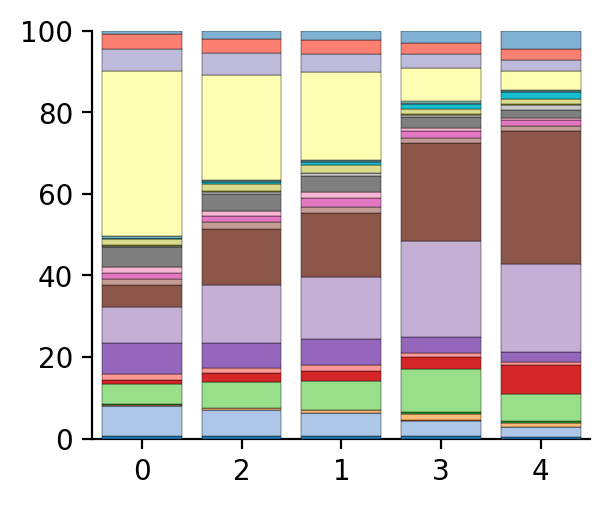

  cluster  weighted_prop   total
0       0      14.970339  110853
1       2       8.605925   61232
2       1       6.372723   95304
3       3       2.632171  225499
4       4       1.134710   65437


In [29]:
# ---------------------------
# 1) Cell-type distributions via mg.pl.cell_type_distributions
# ---------------------------
import anndata as ad
import MINGLE as mg

adata_for_pl = ad.AnnData(obs=total_df.copy())
adata_for_pl.obs_names = adata_for_pl.obs.index.astype(str)

fig, ax, rank_df, combined_perc = mg.pl.cell_type_distributions(
    adata_for_pl,
    neighborhoods_to_plot=(inner_name, outer_name),
    min_cells=10,
    cluster_key='Probability_Bin_Cluster',
    score_key='Score',
    cell_type_key='Cell Type',
    neighborhood_key='Neighborhood',
    store_key='plasma_secretory_combined_stacked',
    return_fig=True,
)

print(rank_df.head(20))


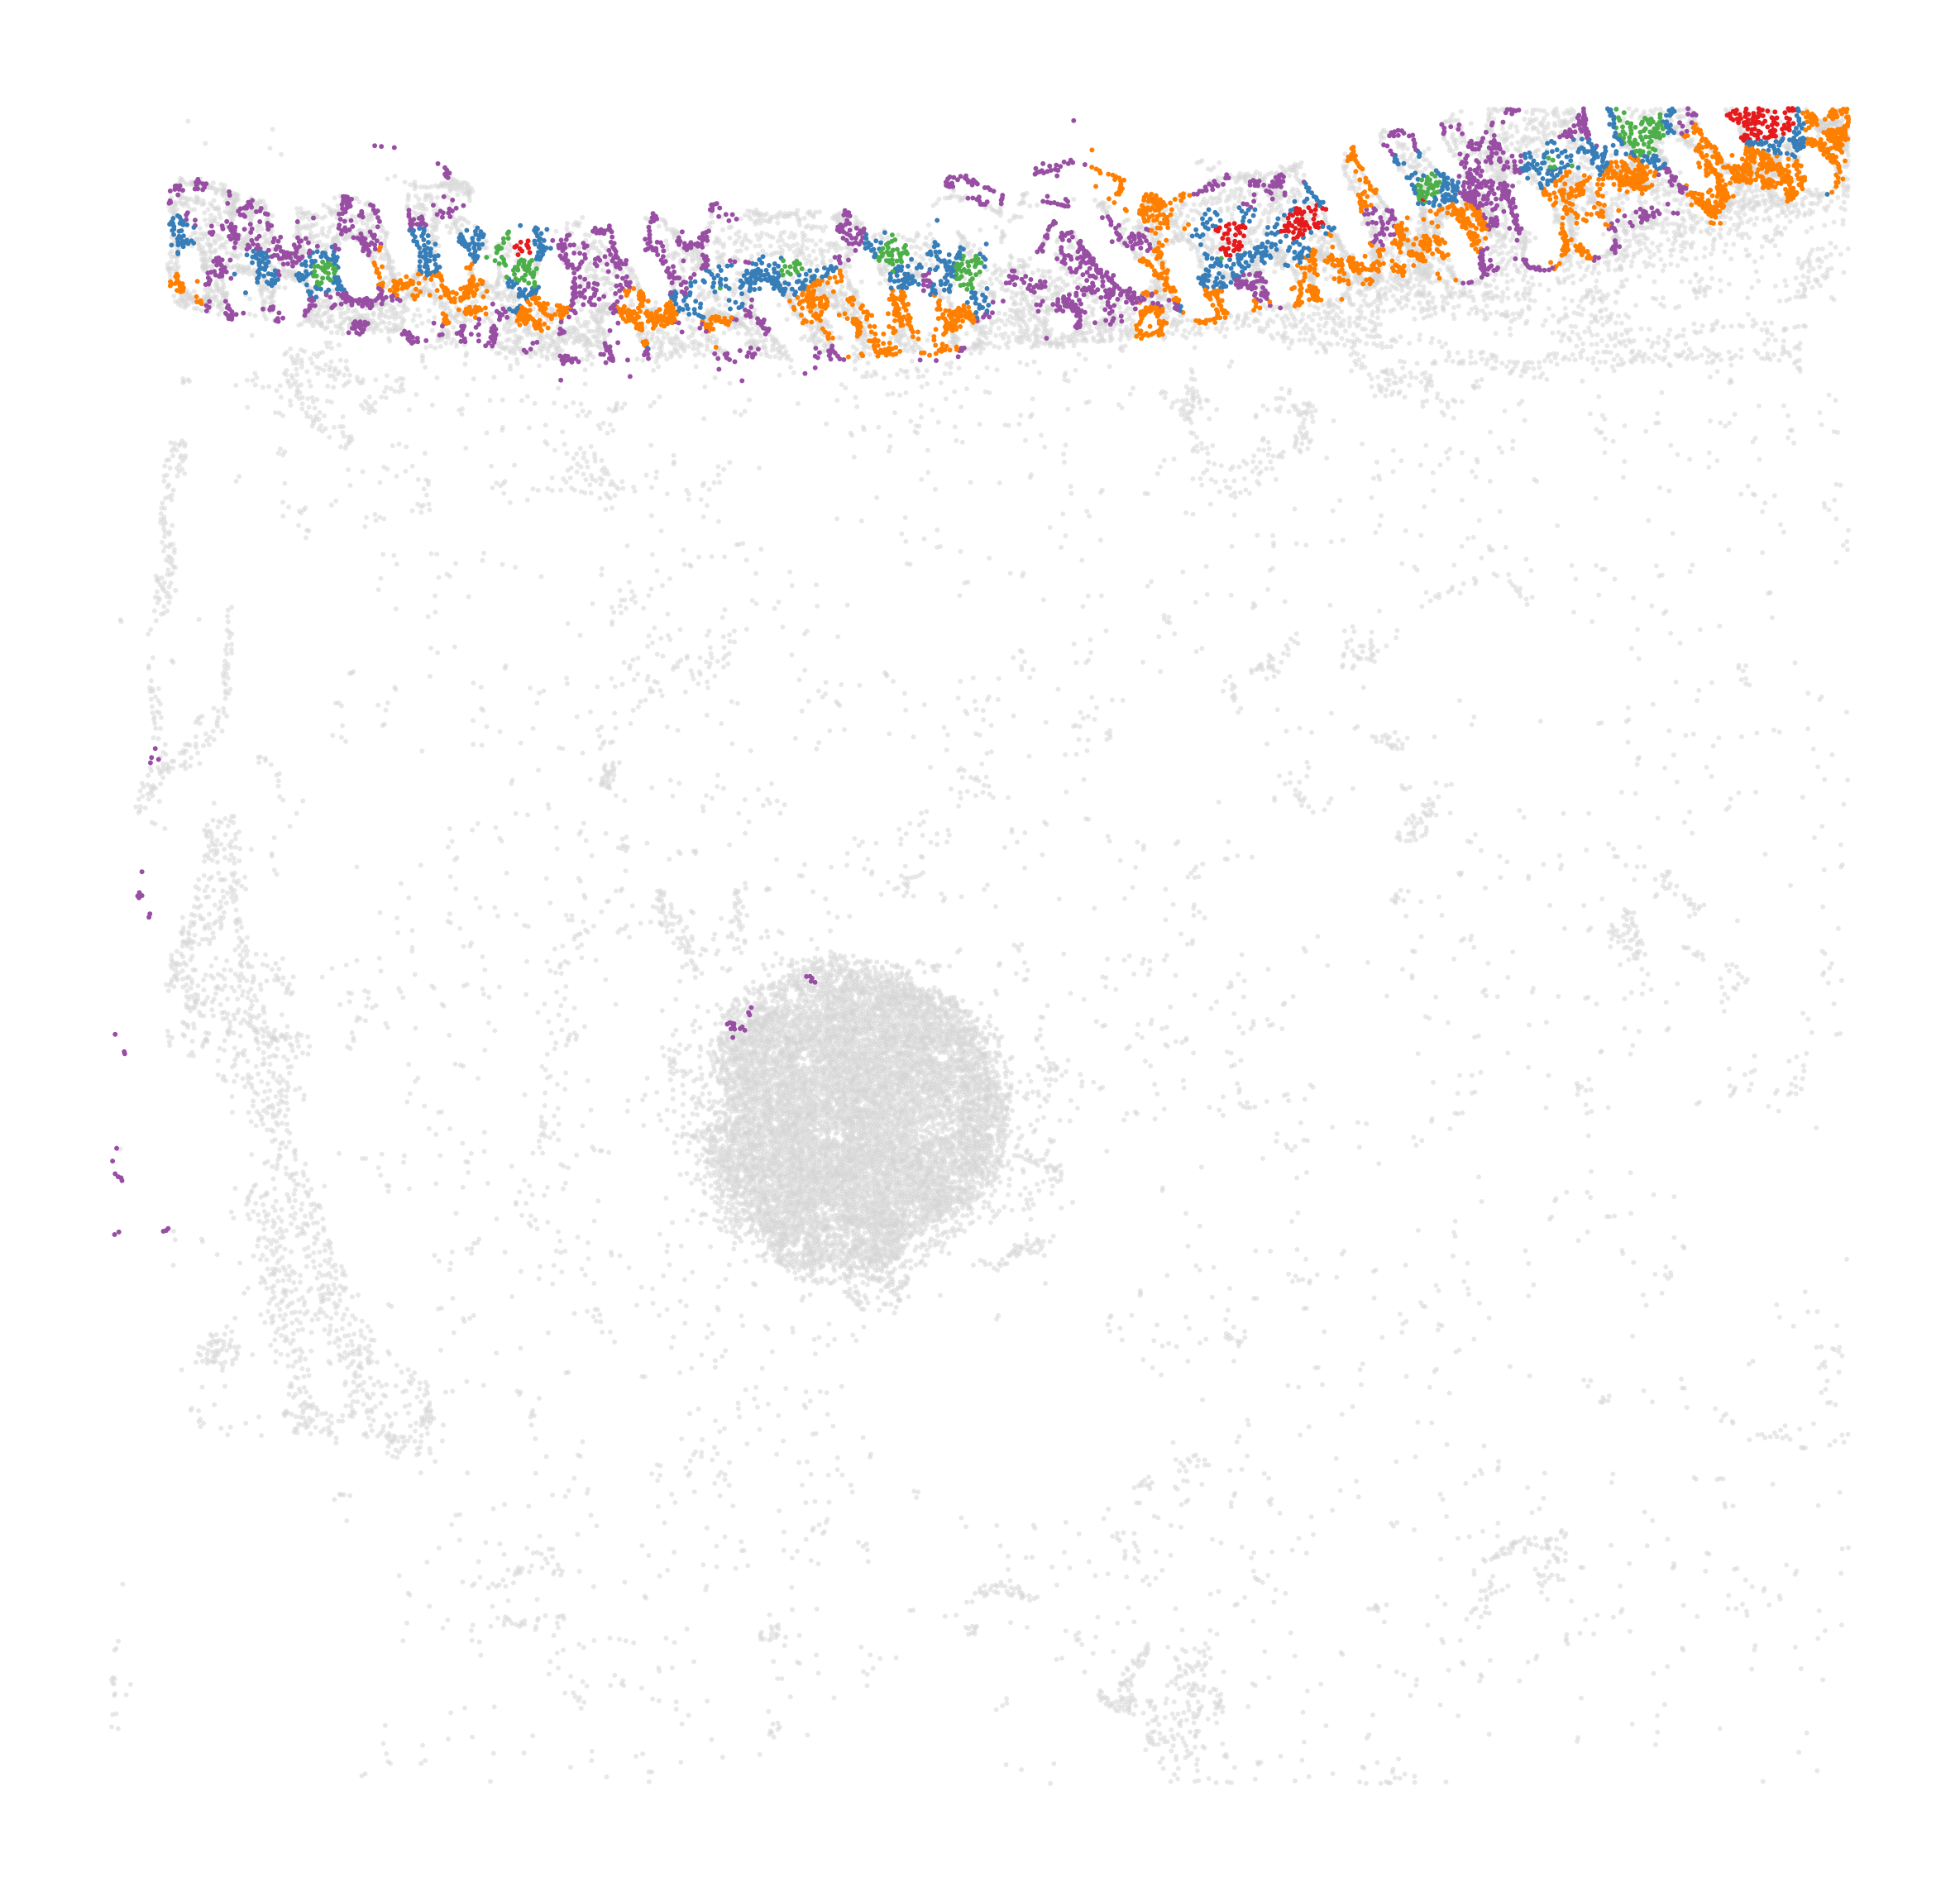

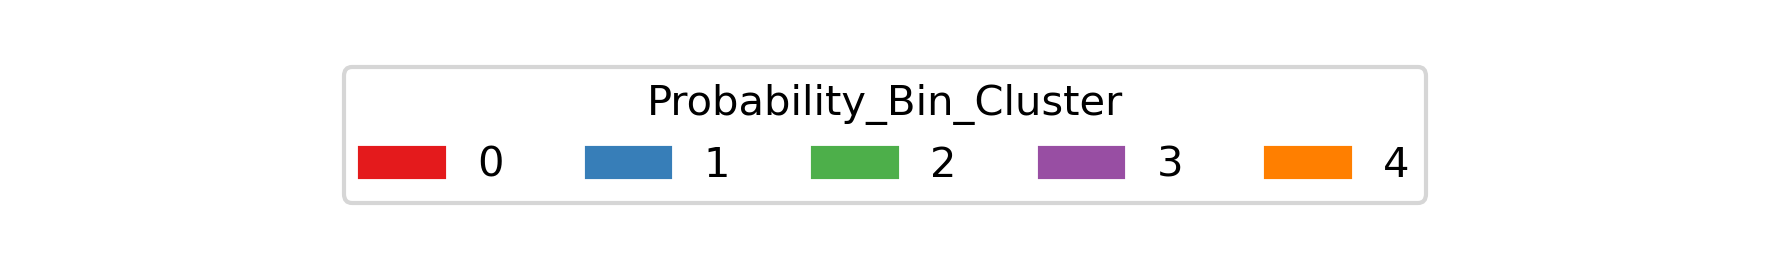

Region plotted: B006_Descending - Sigmoid
Background cells from df: 19321
Colored cells from total_df: 5264


In [30]:
# ---------------------------
# 2) Spatial clustering plot (colored target neighborhoods on gray background)
# ---------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------- User settings ----------------
target_region = 'B006_Descending - Sigmoid'
neigh_inner = inner_name
neigh_outer = outer_name

cluster_col_total = 'Probability_Bin_Cluster'
palette = loaded_palette_hex

dpi_val = 300
marker_size_bg = 2
marker_size_high = 2
alpha_bg = 0.5
alpha_high = 1

bg_color = 'lightgray'
round_dec = 4
# ------------------------------------------------

# Defensive copies
df_all = df_probabilities.copy()
total = total_df.copy()

# 1) Subset region for df (BACKGROUND)
region_df = df_all[df_all['unique_region'] == target_region].copy()

# 2) Subset region for target neighborhoods (colored points)
colored_df = total[
    (total['unique_region'] == target_region) &
    (total['Neighborhood'].isin([neigh_inner, neigh_outer]))
].copy()

# 3) Build cluster color map from total_df clusters only
cluster_vals = sorted(colored_df[cluster_col_total].dropna().unique())
color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(cluster_vals)}

# 4) Deduplicate (remove colored cells from df)
id_cols = ['cell_id', 'cellID', 'CellID', 'unique_cell_id', 'uid', 'id']
id_col = next((c for c in id_cols if c in colored_df.columns and c in region_df.columns), None)

if id_col is not None:
    colored_ids = set(colored_df[id_col].dropna().astype(str))
    mask_colored_in_region = region_df[id_col].astype(str).isin(colored_ids)
elif set(colored_df.index).issubset(set(region_df.index)):
    mask_colored_in_region = region_df.index.isin(colored_df.index)
else:
    if {'x', 'y'}.issubset(colored_df.columns) and {'x', 'y'}.issubset(region_df.columns):
        colored_xy = set(zip(
            np.round(colored_df['x'].astype(float), round_dec),
            np.round(colored_df['y'].astype(float), round_dec)
        ))
        region_xy = list(zip(
            np.round(region_df['x'].astype(float), round_dec),
            np.round(region_df['y'].astype(float), round_dec)
        ))
        mask_colored_in_region = pd.Series([xy in colored_xy for xy in region_xy], index=region_df.index)
    else:
        mask_colored_in_region = pd.Series(False, index=region_df.index)

background_df = region_df.loc[~mask_colored_in_region].copy()

# 5) Apply colors based on cluster
def cluster_to_color(series):
    return series.map(color_map).fillna(bg_color)

colored_df['plot_color'] = cluster_to_color(colored_df[cluster_col_total])

# 6) PLOT (NO LEGEND, NO OUTLINES)
fig, ax = plt.subplots(figsize=(8, 8), dpi=dpi_val)

if not background_df.empty:
    ax.scatter(
        background_df['x'], background_df['y'],
        c=bg_color,
        s=marker_size_bg,
        alpha=alpha_bg,
        linewidths=0,
        edgecolors='none'
    )

ax.scatter(
    colored_df['x'],
    colored_df['y'],
    c=colored_df['plot_color'],
    s=marker_size_high,
    alpha=alpha_high,
    linewidths=0,
    edgecolors='none'
)

ax.axis('off')
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

# 7) (Optional) Separate cluster legend
patches = [Patch(color=color_map[cl], label=str(cl)) for cl in cluster_vals]
fig_leg, ax_leg = plt.subplots(figsize=(6, 0.4 + len(patches) * 0.12), dpi=dpi_val)
ax_leg.axis('off')
ax_leg.legend(handles=patches, title='Probability_Bin_Cluster', loc='center', ncol=min(8, len(patches)))
plt.tight_layout()
plt.show()

print(f'Region plotted: {target_region}')
print(f'Background cells from df: {len(background_df)}')
print(f'Colored cells from total_df: {len(colored_df)}')


/opt/anaconda3/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


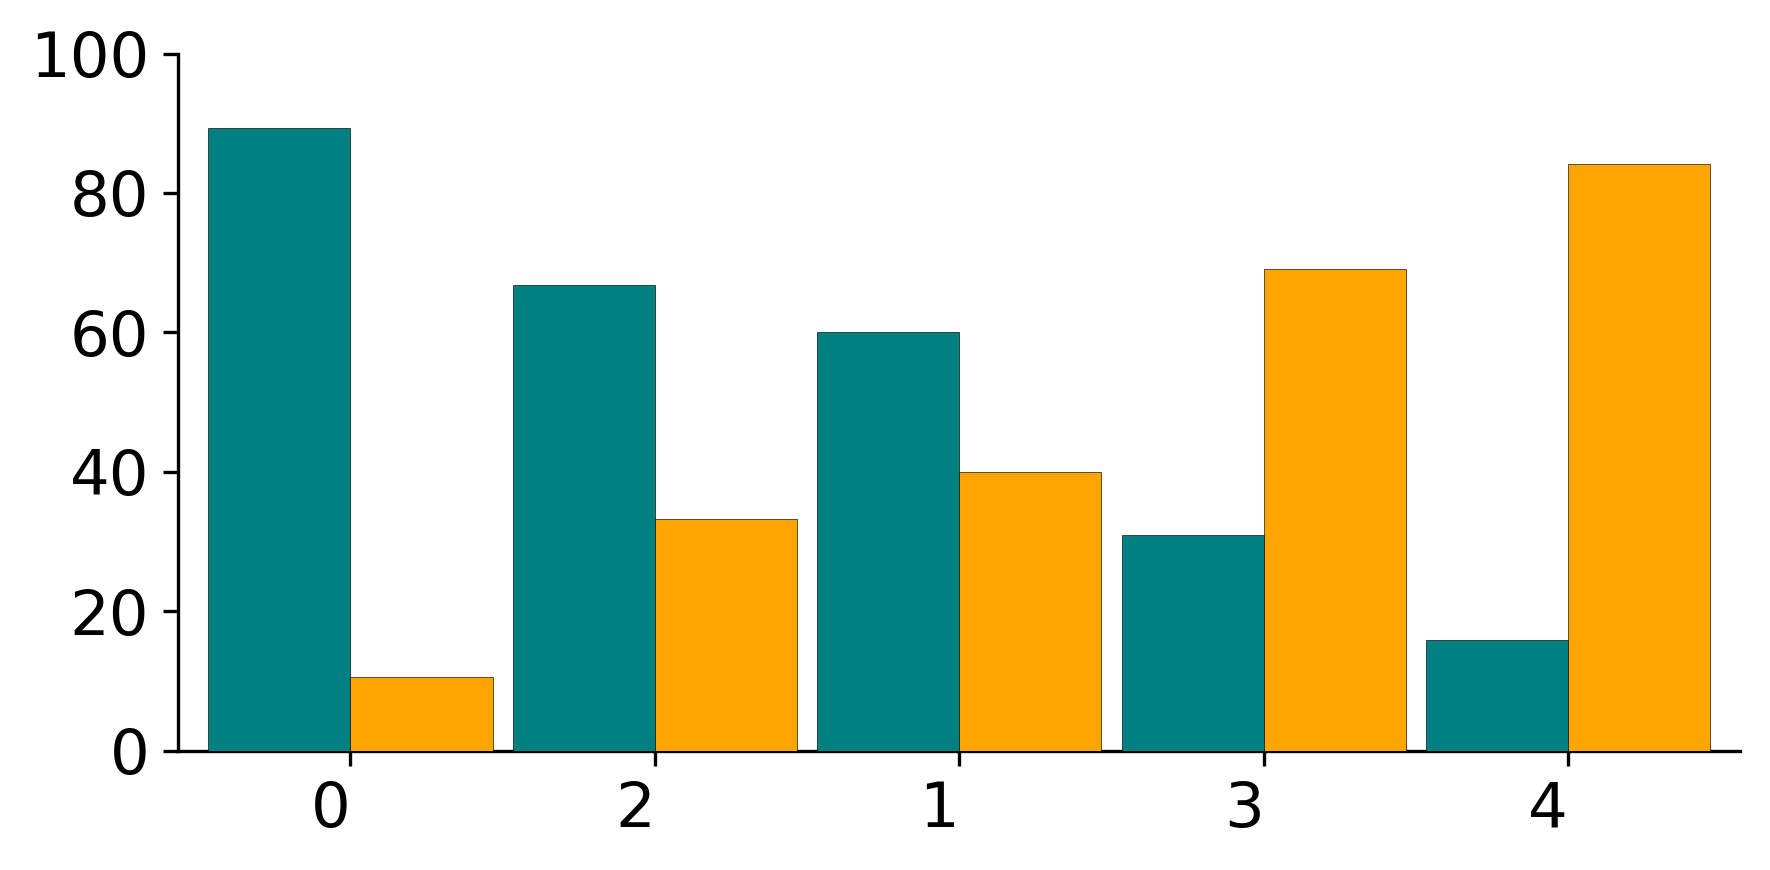

/Users/jamesw/Desktop/Mingle/src/MINGLE/tl/gb.py:307: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


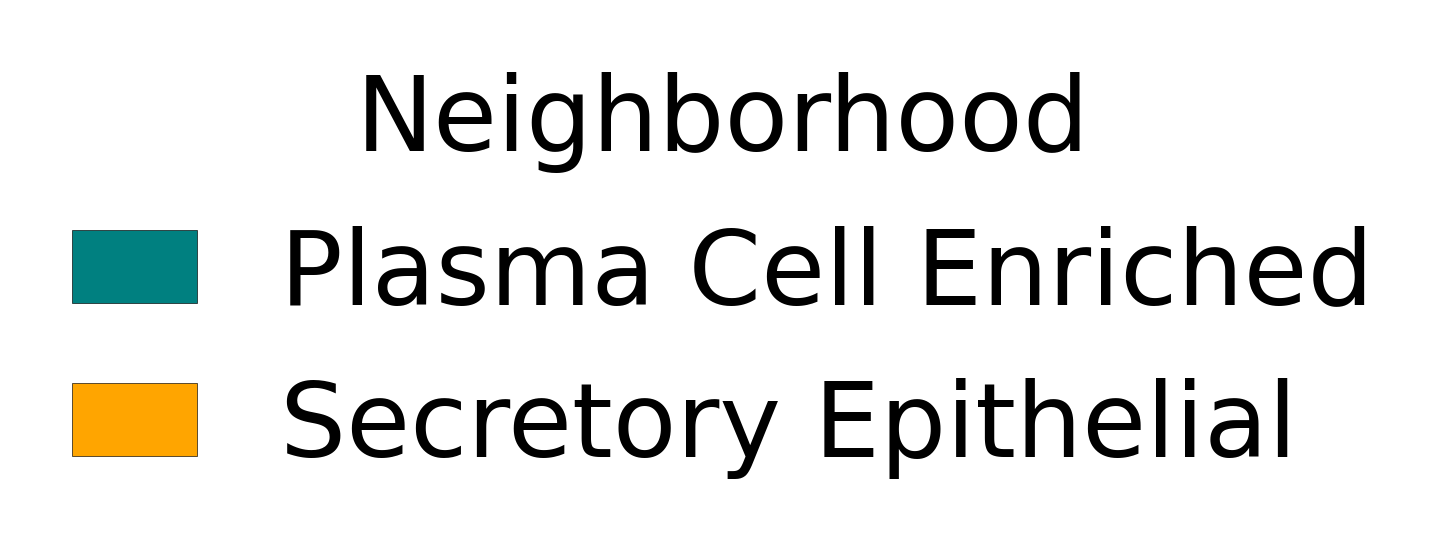

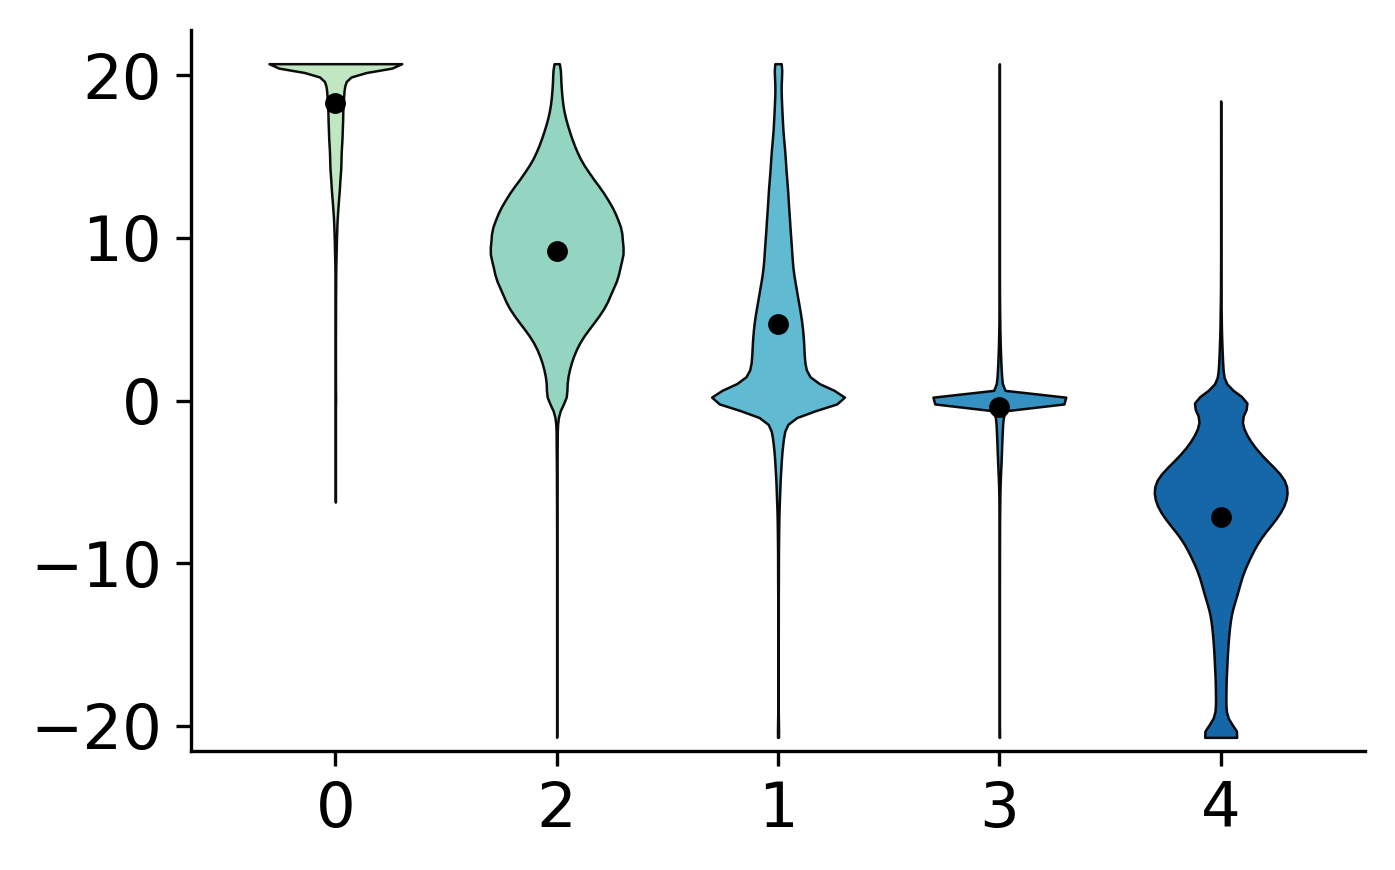

Local gradients (B006_Descending - Sigmoid): 100%|██████████| 5264/5264 [00:00<00:00, 6125.42pt/s]


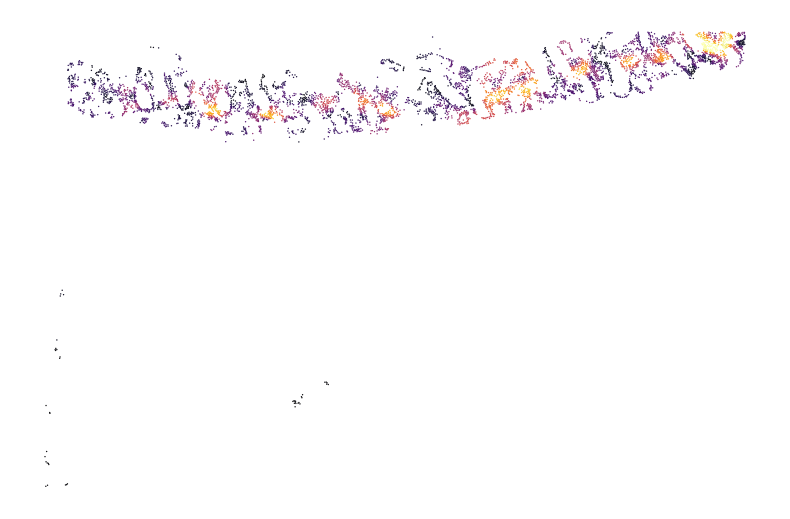

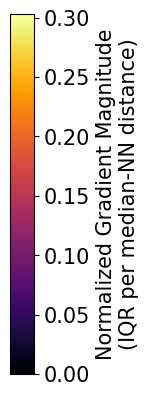

  cluster  inner_pct  outer_pct   total
0       0  89.349860  10.650140  110853
1       2  66.772276  33.227724   61232
2       1  60.045748  39.954252   95304
3       3  30.964661  69.035339  225499
4       4  15.888565  84.111435   65437
Summary: {'region_key': 'unique_region', 'region_value': 'B006_Descending - Sigmoid', 'n_points_used': 5264, 'n_valid_grad': 5264, 'd_med': 14.866068747318506, 'score_iqr': 6.132797146902343, 'score_range': 41.4465315958644, 'normalize_by': 'iqr', 'median_grad_mag_norm': 0.0780365922055232, 'mean_grad_mag_norm': 0.09856269193040025}


In [35]:
# ---------------------------
# 3) Graphs via mg.tl.gb
# ---------------------------
import anndata as ad
import MINGLE as mg

df_for_gb = total_df.copy()

adata_gb = ad.AnnData(obs=df_for_gb.copy())
adata_gb.obs_names = adata_gb.obs.index.astype(str)

region_value_gb = target_region

out = mg.tl.gb(
    adata_gb,
    cluster_key='Probability_Bin_Cluster',
    score_key='Score',
    neighborhood_key='Neighborhood',
    inner_name=inner_name,
    outer_name=outer_name,
    min_cells=10,
    pb_prefix='pb',
    region_key='unique_region',
    region_value=region_value_gb,
    x_key='x',
    y_key='y',
    k_neighbors=100,
    normalize_by='iqr',
    grad_prefix='grad',
    make_plots=True,
)

if 'pb_agg_df' in adata_gb.uns:
    print(adata_gb.uns['pb_agg_df'])
if 'grad_summary' in adata_gb.uns:
    print('Summary:', adata_gb.uns['grad_summary'])


In [32]:
# ---------------------------
# 4) Setup for small-multiples cell-type subplot
# ---------------------------
import numpy as np
import pandas as pd
import seaborn as sns

canonical_bins = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
weights = {b: 2 ** i for i, b in enumerate(canonical_bins)}

rank_src = total_df.copy()
rank_src['_cluster_str'] = rank_src['Probability_Bin_Cluster'].astype(str).str.strip()

try:
    mapped = pd.qcut(rank_src['Score'], q=[0, .2, .4, .6, .8, 1.0], labels=canonical_bins, duplicates='drop')
    rank_src['_bin_mapped'] = mapped.astype(object)
except Exception:
    v = pd.to_numeric(rank_src['Score'], errors='coerce')
    edges = np.linspace(float(v.min()), float(v.max()), len(canonical_bins) + 1)
    u = np.unique(edges)
    labels_use = canonical_bins[:max(1, len(u) - 1)]
    rank_src['_bin_mapped'] = pd.cut(v, bins=u, labels=labels_use, include_lowest=True).astype(object)

cluster_keys = sorted(rank_src['_cluster_str'].dropna().unique(), key=str)
rank_rows = []
for cl in cluster_keys:
    sub = rank_src[rank_src['_cluster_str'] == cl]
    n = len(sub)
    if n == 0:
        continue
    vc = sub['_bin_mapped'].value_counts(dropna=False).to_dict()
    props = {b: vc.get(b, 0) / n for b in canonical_bins}
    weighted_prop = sum(props[b] * weights[b] for b in canonical_bins)
    rank_rows.append({'cluster': cl, 'weighted_prop': weighted_prop, 'total': n})

rank_df_ct = pd.DataFrame(rank_rows).sort_values(['weighted_prop', 'total'], ascending=[False, False]).reset_index(drop=True)
global_cluster_order = rank_df_ct['cluster'].tolist()

inner_subset = total_df[total_df['Neighborhood'].astype(str).str.lower() == inner_name.lower()].copy()
outer_subset = total_df[total_df['Neighborhood'].astype(str).str.lower() == outer_name.lower()].copy()

inner_subset['_cluster_str'] = inner_subset['Probability_Bin_Cluster'].astype(str).str.strip()
outer_subset['_cluster_str'] = outer_subset['Probability_Bin_Cluster'].astype(str).str.strip()

min_cells = 10
clusters_ok = []
for cl in global_cluster_order:
    if (inner_subset['_cluster_str'] == cl).sum() >= min_cells and (outer_subset['_cluster_str'] == cl).sum() >= min_cells:
        clusters_ok.append(cl)

inner_order = clusters_ok
combined_subset = pd.concat([inner_subset, outer_subset], ignore_index=True)

cell_type_list = sorted(combined_subset['Cell Type'].dropna().astype(str).unique().tolist())
palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
combined_colors = []
for name in palette_names:
    combined_colors.extend(sns.color_palette(name))

color_dict = dict(zip(cell_type_list, combined_colors[:len(cell_type_list)]))

print('Prepared small-multiples inputs.')
print('inner_order:', inner_order)
print('cell types:', len(cell_type_list))


Prepared small-multiples inputs.
inner_order: ['0', '2', '1', '3', '4']
cell types: 25


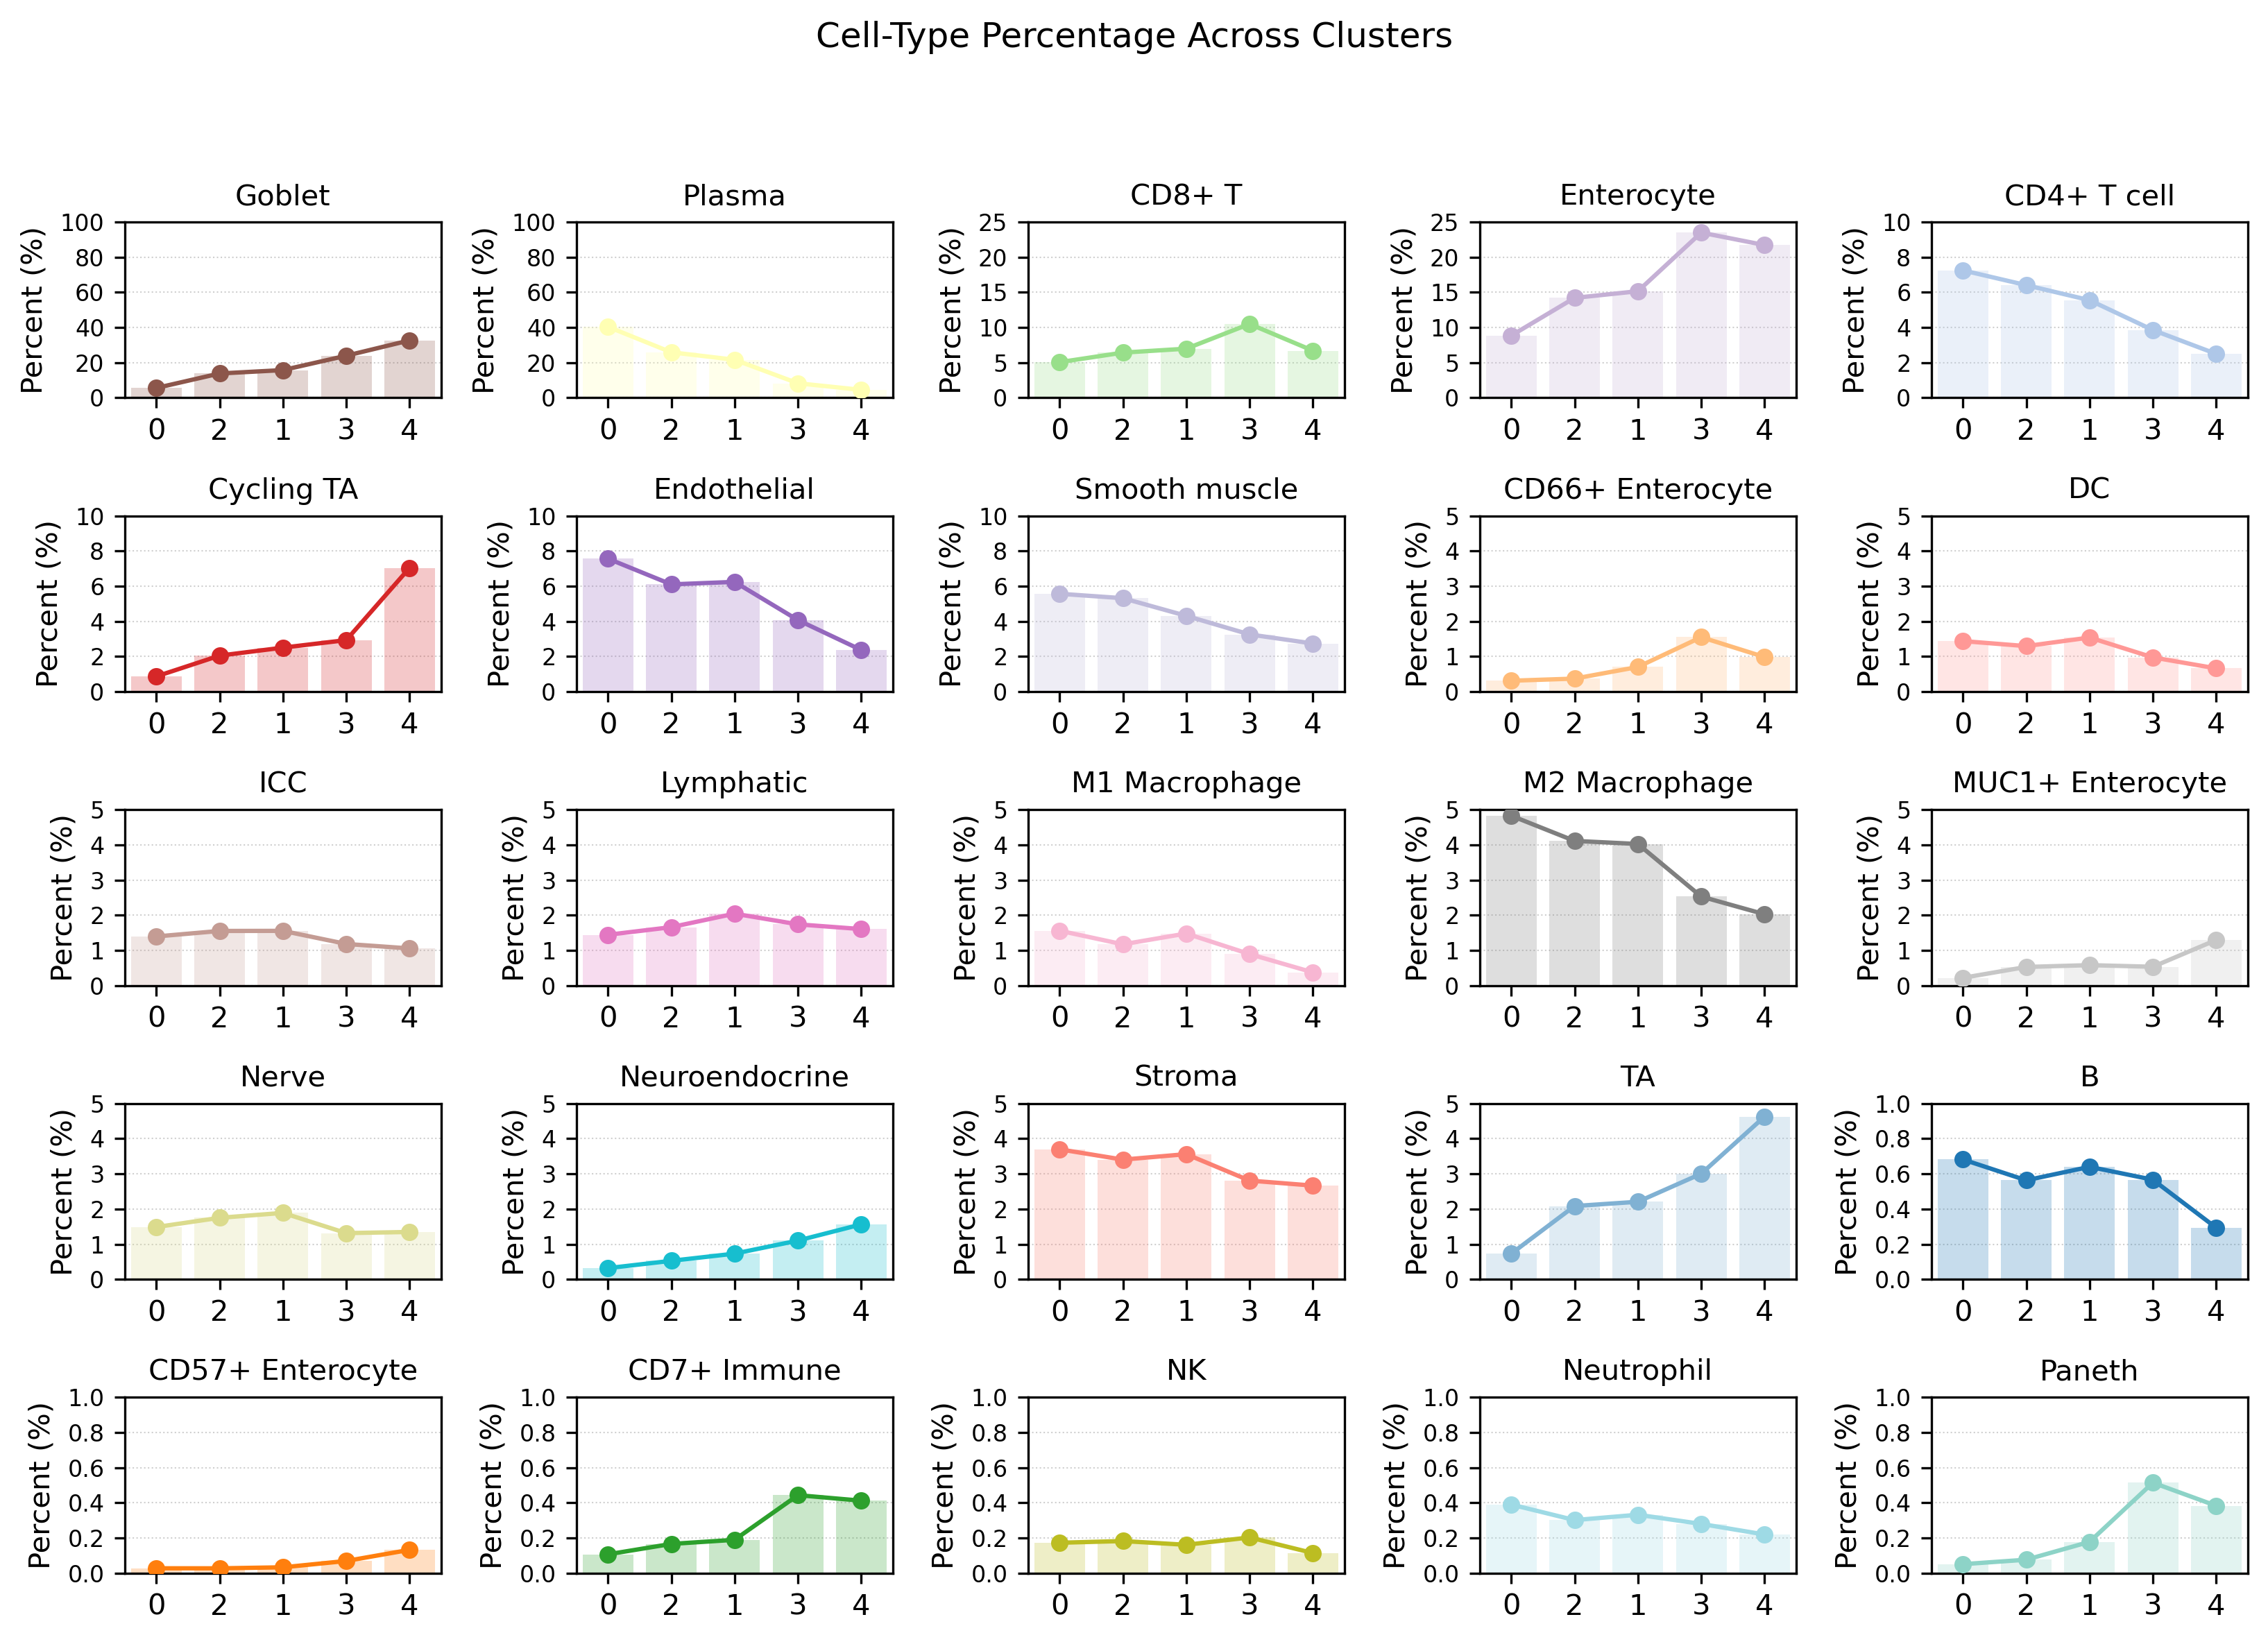

In [33]:
# ---------------------------
# 4) Cell graphs: small-multiples per cell type
# ---------------------------
import math
import matplotlib.pyplot as plt
import numpy as np

cluster_order = inner_order
num_clusters = len(cluster_order)

ct_list = list(cell_type_list)

# ------------------------------------------------
# Helper: compute percent per cluster for each cell type
# ------------------------------------------------
def compute_percent_matrix_combined(full_df_subset, cluster_order, cell_types):
    ct_series = full_df_subset['Cell Type'].astype(str)
    perc = {ct: np.zeros(len(cluster_order)) for ct in cell_types}
    for i, cl in enumerate(cluster_order):
        mask = full_df_subset['_cluster_str'] == cl
        total = int(mask.sum())
        for ct in cell_types:
            perc[ct][i] = ((mask) & (ct_series == ct)).sum() / total * 100.0 if total > 0 else 0.0
    return perc

perc_matrix = compute_percent_matrix_combined(combined_subset, cluster_order, ct_list)

# ------------------------------------------------
# Decide y-range per cell type
# ------------------------------------------------
AVAILABLE_RANGES = [1, 5, 10, 25, 100]
TICK_SPACING = {
    1: 0.2,
    5: 1,
    10: 2,
    25: 5,
    100: 20,
}

celltype_meta = []
for ct in ct_list:
    y = perc_matrix[ct]
    observed_max = float(np.nanmax(y)) if len(y) > 0 else 0.0

    chosen_range = None
    for r in AVAILABLE_RANGES:
        if observed_max <= r:
            chosen_range = r
            break

    if chosen_range is None:
        chosen_range = 100

    if observed_max == 0:
        chosen_range = 1

    celltype_meta.append((ct, chosen_range))

# ------------------------------------------------
# ORDER subplots: largest y-range first
# ------------------------------------------------
celltype_meta_sorted = sorted(celltype_meta, key=lambda x: x[1], reverse=True)
ordered_cell_types = [ct for ct, _ in celltype_meta_sorted]
range_lookup = dict(celltype_meta_sorted)

# ------------------------------------------------
# Plotting grid
# ------------------------------------------------
n_celltypes = len(ordered_cell_types)
ncols = min(5, n_celltypes)
nrows = int(math.ceil(n_celltypes / ncols))

fig_w = max(4, 2.2 * ncols)
fig_h = max(2, 1.6 * nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=300, squeeze=False)
axes_flat = axes.flatten()

x = np.arange(num_clusters)
x_labels = [str(c) for c in cluster_order]

for i, ct in enumerate(ordered_cell_types):
    ax = axes_flat[i]
    y = perc_matrix[ct]
    color = color_dict.get(ct, (0.4, 0.4, 0.4))

    chosen_range = range_lookup[ct]

    ax.plot(x, y, marker='o', linewidth=1.5, markersize=5, color=color, zorder=4)
    ax.bar(x, y, alpha=0.25, color=color, edgecolor='none', zorder=2)

    ax.set_ylim(0, chosen_range)
    spacing = TICK_SPACING[chosen_range]
    yticks = np.arange(0, chosen_range + 1e-9, spacing)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:.1f}' if chosen_range == 1 else f'{int(t)}' for t in yticks], fontsize=8)

    ax.set_title(f'{ct}', fontsize=10, pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=10)

    ax.set_xlim(-0.5, num_clusters - 0.5)
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.set_ylabel('Percent (%)', fontsize=10)

for j in range(n_celltypes, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Cell-Type Percentage Across Clusters', fontsize=12)
plt.tight_layout(rect=[0, 0.0, 1, 0.94])
plt.show()


/var/folders/6b/mntkh0r931zc2_rw968nmljh0000gn/T/ipykernel_57877/2967245413.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  slope = float(lr.coef_[0])


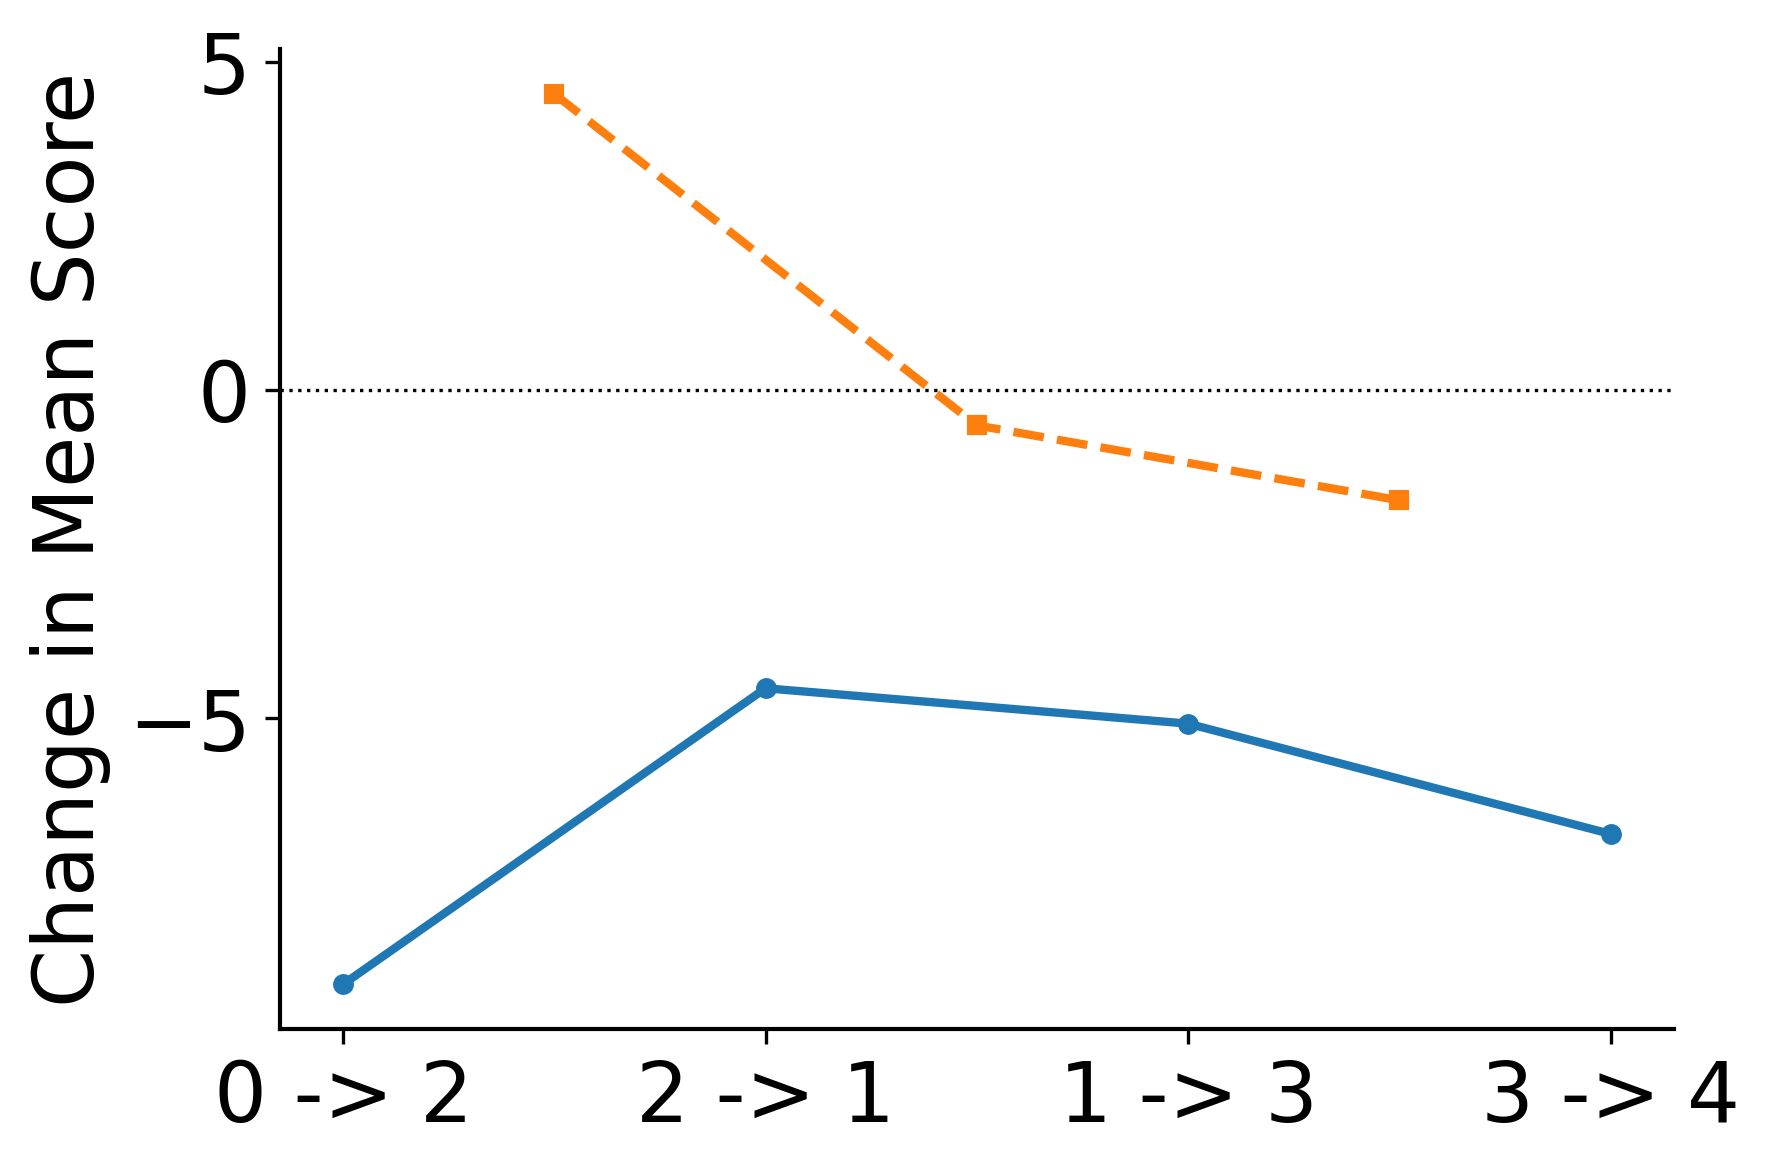

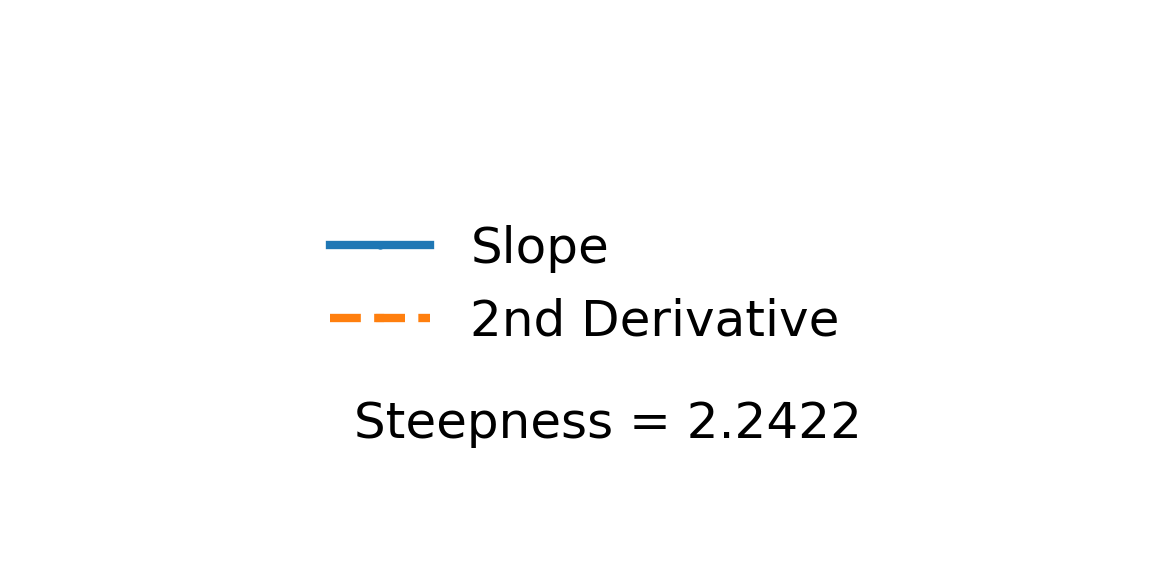

Clusters plotted (order): ['0', '2', '1', '3', '4']
First derivative (Δ mean score): [-9.05022  -4.541875 -5.080442 -6.760257]
Second derivative (Δ of Δ): [ 4.508345 -0.538568 -1.679815]
Global slope = -6.04879
Normalized slope (slope / IQR) = 0.535241 IQR/cluster
Steepness (mean |2nd derivative| / IQR) = 2.24224


In [34]:
# ---------------------------
# 5) Global steepness graph
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import pandas as pd

df_plot = total_df.copy()

cluster_col = 'Probability_Bin_Cluster'
score_col = 'Score'
n_bins = 5

# --------------------------------------------------
# Cluster ordering helper
# --------------------------------------------------
def _compute_cluster_order_score_weighted_local(df_in, cluster_col, score_col, n_bins=5):
    canonical_bins = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    weights = {b: 2**i for i, b in enumerate(canonical_bins)}

    d = df_in.copy()
    d['cluster_str'] = d[cluster_col].astype(str).str.strip()

    s = pd.to_numeric(d[score_col], errors='coerce')
    try:
        mapped = pd.qcut(s, q=n_bins, labels=canonical_bins, duplicates='drop')
        d['_bin_mapped'] = mapped.astype(object)
    except Exception:
        v = s.dropna()
        edges = np.linspace(float(v.min()), float(v.max()), n_bins + 1)
        u = np.unique(edges)
        labels_use = canonical_bins[:max(1, len(u) - 1)]
        d['_bin_mapped'] = pd.cut(s, bins=u, labels=labels_use, include_lowest=True).astype(object)

    cluster_keys = sorted(d['cluster_str'].dropna().unique(), key=str)
    rows = []
    for cl in cluster_keys:
        sub = d[d['cluster_str'] == cl]
        n = len(sub)
        if n == 0:
            continue
        vc = sub['_bin_mapped'].value_counts(dropna=False).to_dict()
        props = {b: vc.get(b, 0) / n for b in canonical_bins}
        weighted_prop = sum(props[b] * weights[b] for b in canonical_bins)
        rows.append({'cluster': cl, 'weighted_prop': weighted_prop, 'total': n})

    rank_df_local = pd.DataFrame(rows).sort_values(['weighted_prop', 'total'], ascending=[False, False]).reset_index(drop=True)
    return rank_df_local['cluster'].tolist()

ordered_clusters = [str(x) for x in _compute_cluster_order_score_weighted_local(df_plot, cluster_col, score_col, n_bins=n_bins)]

# --------------------------------------------------
# Compute mean score per cluster IN THAT ORDER
# --------------------------------------------------
agg = df_plot.groupby(df_plot[cluster_col].astype(str))[score_col].mean()
clusters_in_plot = [c for c in ordered_clusters if c in agg.index]
means = agg.loc[clusters_in_plot].values.astype(float)

n = len(means)
if n < 2:
    raise ValueError('Need at least 2 clusters to compute derivatives.')

# --------------------------------------------------
# Global slope (for reference only)
# --------------------------------------------------
X = np.arange(n).reshape(-1, 1)
y = means.reshape(-1, 1)
lr = LinearRegression().fit(X, y)
slope = float(lr.coef_[0])

score_vals = pd.to_numeric(df_plot[score_col], errors='coerce').dropna().values
q1, q3 = np.percentile(score_vals, [25, 75])
iqr = max(1e-8, q3 - q1)
slope_norm = abs(slope) / iqr

# --------------------------------------------------
# First and second derivatives (RAW — NO NORMALIZATION)
# --------------------------------------------------
fd = np.diff(means)
sd = np.diff(fd) if len(fd) >= 2 else np.array([])

# --------------------------------------------------
# Steepness calculation updated: mean absolute second derivative
# --------------------------------------------------
if sd.size:
    steepness = float(np.mean(np.abs(sd)))
else:
    steepness = float('nan')

labels_fd = [f'{clusters_in_plot[i]} -> {clusters_in_plot[i+1]}' for i in range(len(fd))]

x_fd = np.arange(len(fd))
x_sd = x_fd[:len(sd)] + 0.5

# --------------------------------------------------
# Main plot (clean)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(
    x_fd, fd,
    marker='o', markersize=4,
    linewidth=2,
    color='#1f77b4',
    label='Slope'
)

if sd.size:
    ax.plot(
        x_sd, sd,
        marker='s', markersize=4,
        linewidth=2,
        linestyle='--',
        color='#ff7f0e',
        label='2nd Derivative'
    )

ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

ax.set_xticks(x_fd)
ax.set_xticklabels(labels_fd, rotation=0, ha='center', fontsize=20)
ax.set_ylabel('Change in Mean Score', fontsize=20)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Separate legend figure (small markers, clean)
# --------------------------------------------------
legend_handles = [
    Line2D([0], [0], color='#1f77b4', lw=2, marker='o', markersize=1, label='Slope'),
    Line2D([0], [0], color='#ff7f0e', lw=2, linestyle='--', marker='s', markersize=1, label='2nd Derivative')
]

legend_text = f'Steepness = {steepness:.4f}'

fig_leg, ax_leg = plt.subplots(figsize=(4, 2), dpi=300)
ax_leg.axis('off')

ax_leg.legend(
    handles=legend_handles,
    loc='center',
    frameon=False,
    fontsize=12,
    handlelength=2.0
)

ax_leg.text(
    0.75, 0.18,
    legend_text,
    ha='right', va='bottom',
    transform=ax_leg.transAxes,
    fontsize=12
)

plt.tight_layout()
plt.show()

print('Clusters plotted (order):', clusters_in_plot)
print('First derivative (Δ mean score):', np.round(fd, 6))
if sd.size:
    print('Second derivative (Δ of Δ):', np.round(sd, 6))
print(f'Global slope = {slope:.6g}')
print(f'Normalized slope (slope / IQR) = {slope_norm:.6g} IQR/cluster')
print(f'Steepness (mean |2nd derivative| / IQR) = {steepness:.6g}')
